In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
import shap
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "#0f0f0f", "axes.facecolor": "#1a1a1a",
    "axes.edgecolor": "#444", "axes.labelcolor": "white",
    "xtick.color": "white", "ytick.color": "white",
    "text.color": "white", "grid.color": "#333",
    "grid.linestyle": "--", "grid.alpha": 0.5,
})

df = pd.read_csv("./data/processed/indian_films_cleaned.csv")
bo = df[df["has_boxoffice"]].copy()
print(f"Modelling dataset: {len(bo)} films")

Modelling dataset: 198 films


In [6]:
import ast

# One-hot encode top genres
ALL_GENRES = ["Drama", "Action", "Comedy", "Romance", "Thriller", "Crime", "Family", "Horror"]

def has_genre(genres_str, genre):
    try:
        genres = ast.literal_eval(genres_str)
        return int(genre in genres)
    except:
        return 0

for g in ALL_GENRES:
    bo[f"genre_{g}"] = bo["genres"].apply(lambda x: has_genre(x, g))

# Language dummies
bo["is_hindi"]  = (bo["original_language"] == "hi").astype(int)
bo["is_tamil"]  = (bo["original_language"] == "ta").astype(int)
bo["is_telugu"] = (bo["original_language"] == "te").astype(int)

# Target: log revenue (log-normalises the heavy skew)
bo["log_revenue"] = np.log1p(bo["revenue_clean"])
bo["log_budget"]  = np.log1p(bo["budget_clean"])

# Features
FEATURES = (
    ["bechdel_proxy_score", "female_lead_ratio", "female_cast_ratio",
     "director_gender",     # 1=female, 2=male, 0=unknown
     "log_budget", "runtime", "vote_average", "year",
     "is_hindi", "is_tamil", "is_telugu"]
    + [f"genre_{g}" for g in ALL_GENRES]
)

# Drop rows with any NaN in features or target
model_df = bo[FEATURES + ["log_revenue", "title"]].dropna()
print(f"Clean modelling rows: {len(model_df)}")
print(f"Features: {len(FEATURES)}")

X = model_df[FEATURES]
y = model_df["log_revenue"]

Clean modelling rows: 180
Features: 19


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# 1. Linear Regression (interpretable — important for banking interviews)
lr = LinearRegression()
lr.fit(X_train_s, y_train)
lr_preds = lr.predict(X_test_s)
lr_r2  = r2_score(y_test, lr_preds)
lr_mae = mean_absolute_error(y_test, lr_preds)

# 2. Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_r2  = r2_score(y_test, rf_preds)
rf_mae = mean_absolute_error(y_test, rf_preds)

# 3. Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
gb.fit(X_train, y_train)
gb_preds = gb.predict(X_test)
gb_r2  = r2_score(y_test, gb_preds)
gb_mae = mean_absolute_error(y_test, gb_preds)

# Cross-val scores (more reliable with small dataset)
lr_cv = cross_val_score(LinearRegression(), X_train_s, y_train, cv=5, scoring="r2").mean()
rf_cv = cross_val_score(rf, X_train, y_train, cv=5, scoring="r2").mean()
gb_cv = cross_val_score(gb, X_train, y_train, cv=5, scoring="r2").mean()

print(f"{'Model':<25} {'Test R²':>8} {'CV R²':>8} {'MAE':>8}")
print("-" * 52)
print(f"{'Linear Regression':<25} {lr_r2:>8.3f} {lr_cv:>8.3f} {lr_mae:>8.3f}")
print(f"{'Random Forest':<25} {rf_r2:>8.3f} {rf_cv:>8.3f} {rf_mae:>8.3f}")
print(f"{'Gradient Boosting':<25} {gb_r2:>8.3f} {gb_cv:>8.3f} {gb_mae:>8.3f}")

Model                      Test R²    CV R²      MAE
----------------------------------------------------
Linear Regression            0.408    0.244    0.748
Random Forest                0.321    0.294    0.795
Gradient Boosting            0.221    0.051    0.886


Background dataset has 144 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=144 when initializing the masker.


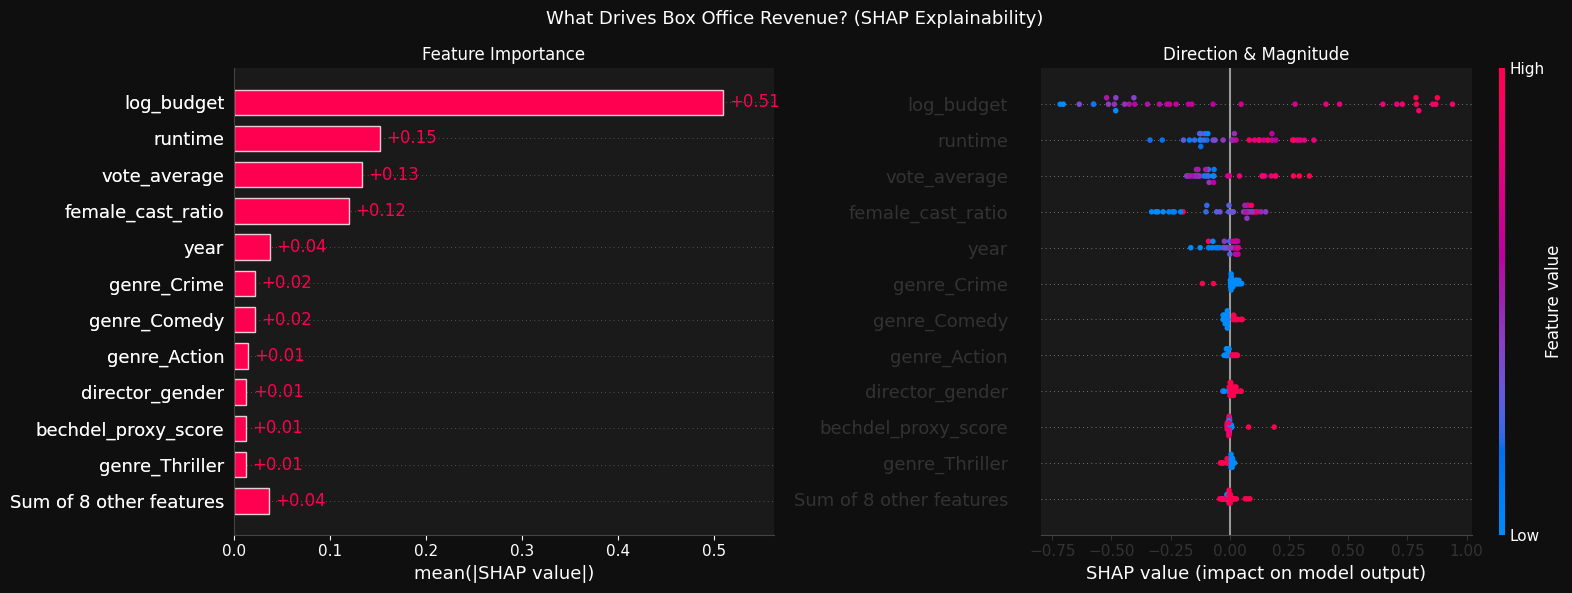

In [10]:
# Install if needed: pip install shap
explainer = shap.Explainer(rf, X_train)
shap_values = explainer(X_test)

fig = plt.figure(figsize=(16, 6))
fig.patch.set_facecolor("#0f0f0f")
fig.suptitle("What Drives Box Office Revenue? (SHAP Explainability)", 
             fontsize=13, color="white")

# Left: feature importance bar
ax1 = fig.add_subplot(1, 2, 1)
shap.plots.bar(shap_values, max_display=12, ax=ax1, show=False)
ax1.set_title("Feature Importance", color="white")
ax1.set_facecolor("#1a1a1a")

# Right: beeswarm needs plot_size=None when using external axes
ax2 = fig.add_subplot(1, 2, 2)
shap.plots.beeswarm(shap_values, max_display=12, ax=ax2, 
                    show=False, plot_size=None)
ax2.set_title("Direction & Magnitude", color="white")
ax2.set_facecolor("#1a1a1a")

plt.tight_layout()
plt.savefig("../visuals/04_shap_explainability.png", dpi=150,
            bbox_inches="tight", facecolor="#0f0f0f")
plt.show()

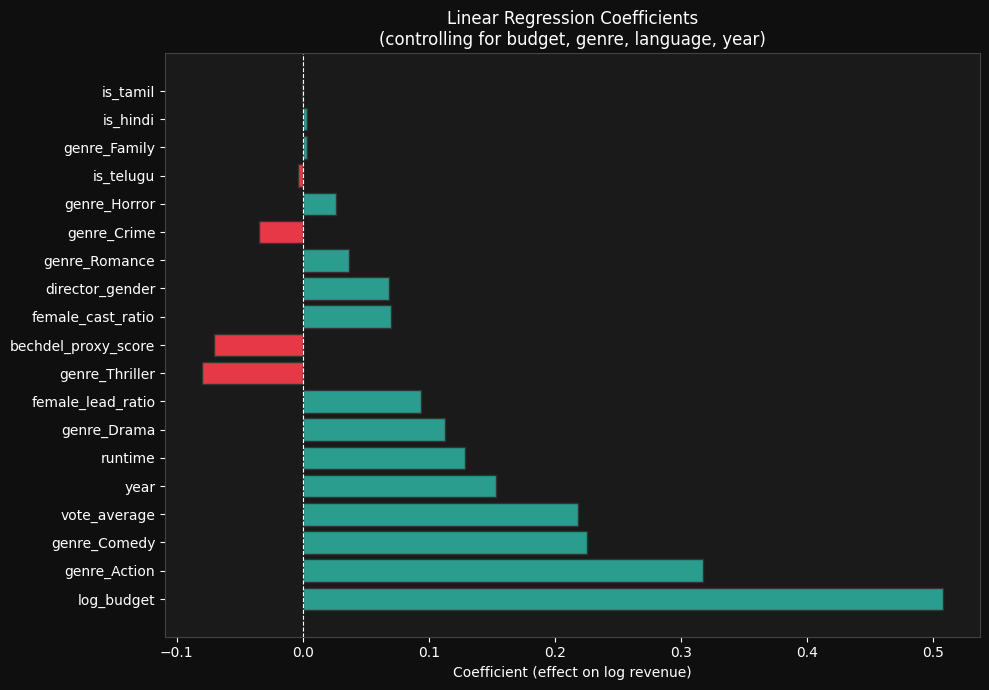


Top features by absolute coefficient:
            feature  coefficient
         log_budget     0.507755
       genre_Action     0.317504
       genre_Comedy     0.225285
       vote_average     0.218150
               year     0.152952
            runtime     0.128595
        genre_Drama     0.113054
  female_lead_ratio     0.093507
     genre_Thriller    -0.079880
bechdel_proxy_score    -0.070012


In [9]:
coef_df = pd.DataFrame({
    "feature": FEATURES,
    "coefficient": lr.coef_
}).sort_values("coefficient", key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors_coef = ["#2a9d8f" if c > 0 else "#e63946" for c in coef_df["coefficient"]]
ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors_coef, edgecolor="#333")
ax.axvline(0, color="white", linewidth=0.8, linestyle="--")
ax.set_title("Linear Regression Coefficients\n(controlling for budget, genre, language, year)",
             color="white", fontsize=12)
ax.set_xlabel("Coefficient (effect on log revenue)")
plt.tight_layout()
plt.savefig("../visuals/05_regression_coefficients.png", dpi=150,
            bbox_inches="tight", facecolor="#0f0f0f")
plt.show()

print("\nTop features by absolute coefficient:")
print(coef_df.head(10).to_string(index=False))